In [1]:
import os, random
import nibabel as nib
import numpy as np
import pandas as pd
from scipy.ndimage import rotate
from sklearn.model_selection import train_test_split

FS_OUTPUT     = "E:/Oasis3/FastSurfer_output"
PET_REG_V2    = "E:/Oasis3/PET_registered_v2"
COHORT_CSV    = "D:/mamba_model/thesis_cohort_final.csv"

WB_MRI_CACHE      = "D:/mamba_model/preprocessed_cache_wholebrain_native_mri"
WB_MRI_CACHE_AUG  = "D:/mamba_model/preprocessed_cache_wholebrain_native_mri_aug"
WB_PET_CACHE      = "D:/mamba_model/preprocessed_cache_wholebrain_native_pet"
WB_PET_CACHE_AUG  = "D:/mamba_model/preprocessed_cache_wholebrain_native_pet_aug"

for d in [WB_MRI_CACHE, WB_MRI_CACHE_AUG, WB_PET_CACHE, WB_PET_CACHE_AUG]:
    os.makedirs(d, exist_ok=True)

AUG_SEEDS = [1, 101, 42]

In [2]:
df = pd.read_csv(COHORT_CSV)
sessions, labels = df["mri_session"].values, df["outcome_label"].values
X_tv, X_test, y_tv, y_test = train_test_split(sessions, labels, test_size=0.2, random_state=42, stratify=labels)
X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=0.25, random_state=42, stratify=y_tv)
session_to_subject = dict(zip(df["mri_session"], df["subject_id"]))

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 126 | Val: 42 | Test: 42


In [3]:
failed_mri = []
for _, row in df.iterrows():
    session_id = row["mri_session"]
    orig_path = f"{FS_OUTPUT}/{session_id}/mri/orig.mgz"
    save_path = f"{WB_MRI_CACHE}/{session_id}.npy"

    if os.path.exists(save_path):
        continue
    if not os.path.exists(orig_path):
        failed_mri.append(session_id)
        continue

    try:
        vol = nib.load(orig_path).get_fdata()
        brain_voxels = vol[vol != 0]
        if len(brain_voxels) > 0 and brain_voxels.std() > 0:
            vol = np.where(vol != 0, (vol - brain_voxels.mean()) / brain_voxels.std(), 0)
        # NO zoom() call -- native resolution kept as-is
        np.save(save_path, vol.astype(np.float32))
        print(f"  MRI {session_id} done -- shape {vol.shape}")
    except Exception as e:
        print(f"  FAILED MRI {session_id}: {e}")
        failed_mri.append(session_id)

print(f"\nMRI extracted: {len(df) - len(failed_mri)}/{len(df)}. Failed: {len(failed_mri)}")
if failed_mri:
    print("Missing:", failed_mri[:10])

  MRI OAS30564_MR_d2808 done -- shape (256, 256, 256)
  MRI OAS31039_MR_d0001 done -- shape (256, 256, 256)
  MRI OAS30473_MR_d0385 done -- shape (256, 256, 256)
  MRI OAS30071_MR_d0018 done -- shape (256, 256, 256)
  MRI OAS30194_MR_d7432 done -- shape (256, 256, 256)
  MRI OAS31085_MR_d0504 done -- shape (256, 256, 256)
  MRI OAS30818_MR_d1214 done -- shape (256, 256, 256)
  MRI OAS30662_MR_d1483 done -- shape (256, 256, 256)
  MRI OAS30830_MR_d0030 done -- shape (256, 256, 256)
  MRI OAS30966_MR_d1923 done -- shape (256, 256, 256)
  MRI OAS30589_MR_d2311 done -- shape (256, 256, 256)
  MRI OAS30612_MR_d0039 done -- shape (256, 256, 256)
  MRI OAS31013_MR_d0039 done -- shape (256, 256, 256)
  MRI OAS30717_MR_d0039 done -- shape (256, 256, 256)
  MRI OAS30978_MR_d0041 done -- shape (256, 256, 256)
  MRI OAS30350_MR_d1201 done -- shape (256, 256, 256)
  MRI OAS31056_MR_d0808 done -- shape (256, 256, 256)
  MRI OAS30949_MR_d1418 done -- shape (256, 256, 256)
  MRI OAS30211_MR_d0046 done

In [4]:
failed_pet = []
for _, row in df.iterrows():
    subject_id = row["subject_id"]
    pet_path = f"{PET_REG_V2}/{subject_id}_PIB_in_MRI.nii.gz"
    save_path = f"{WB_PET_CACHE}/{subject_id}.npy"

    if os.path.exists(save_path):
        continue
    if not os.path.exists(pet_path):
        failed_pet.append(subject_id)
        continue

    try:
        pet = nib.load(pet_path).get_fdata()
        if pet.ndim == 4:
            pet = pet.mean(axis=-1)
        brain_voxels = pet[pet != 0]
        if len(brain_voxels) > 0 and brain_voxels.std() > 0:
            pet = np.where(pet != 0, (pet - brain_voxels.mean()) / brain_voxels.std(), 0)
        # NO zoom() call
        np.save(save_path, pet.astype(np.float32))
        print(f"  PET {subject_id} done -- shape {pet.shape}")
    except Exception as e:
        print(f"  FAILED PET {subject_id}: {e}")
        failed_pet.append(subject_id)

print(f"\nPET extracted: {len(df) - len(failed_pet)}/{len(df)}. Failed: {len(failed_pet)}")
if failed_pet:
    print("Missing:", failed_pet[:10])

  PET OAS30564 done -- shape (256, 256, 256)
  PET OAS31039 done -- shape (256, 256, 256)
  PET OAS30473 done -- shape (256, 256, 256)
  PET OAS30071 done -- shape (256, 256, 256)
  PET OAS30194 done -- shape (256, 256, 256)
  PET OAS31085 done -- shape (256, 256, 256)
  PET OAS30818 done -- shape (256, 256, 256)
  PET OAS30662 done -- shape (256, 256, 256)
  PET OAS30830 done -- shape (256, 256, 256)
  PET OAS30966 done -- shape (256, 256, 256)
  PET OAS30589 done -- shape (256, 256, 256)
  PET OAS30612 done -- shape (256, 256, 256)
  PET OAS31013 done -- shape (256, 256, 256)
  PET OAS30717 done -- shape (256, 256, 256)
  PET OAS30978 done -- shape (256, 256, 256)
  PET OAS30350 done -- shape (256, 256, 256)
  PET OAS31056 done -- shape (256, 256, 256)
  PET OAS30949 done -- shape (256, 256, 256)
  PET OAS30211 done -- shape (256, 256, 256)
  PET OAS30903 done -- shape (256, 256, 256)
  PET OAS30532 done -- shape (256, 256, 256)
  PET OAS30344 done -- shape (256, 256, 256)
  PET OAS3

In [5]:
def augment_wholebrain(vol, seed):
    np.random.seed(seed)
    random.seed(seed)
    augmented = rotate(vol, np.random.uniform(-15, 15), reshape=False, mode="constant", cval=0)
    if np.random.random() > 0.5:
        augmented = augmented[::-1, :, :].copy()
    if np.random.random() > 0.5:
        augmented = augmented[:, ::-1, :].copy()
    return augmented.astype(np.float32)

In [6]:
copied, missing = 0, []
for session_id in df["mri_session"]:
    src = f"{WB_MRI_CACHE}/{session_id}.npy"
    dst = f"{WB_MRI_CACHE_AUG}/{session_id}_orig.npy"
    if os.path.exists(dst):
        continue
    if not os.path.exists(src):
        missing.append(session_id)
        continue
    np.save(dst, np.load(src))
    copied += 1
print(f"MRI: copied {copied} originals. Missing source files: {len(missing)}")

aug_done, aug_failed = 0, []
for seed in AUG_SEEDS:
    for session_id in X_train:
        save_path = f"{WB_MRI_CACHE_AUG}/{session_id}_aug{seed}.npy"
        if os.path.exists(save_path):
            continue
        try:
            orig = np.load(f"{WB_MRI_CACHE_AUG}/{session_id}_orig.npy")
            np.save(save_path, augment_wholebrain(orig, seed))
            aug_done += 1
        except Exception as e:
            print(f"  FAILED MRI {session_id} seed {seed}: {e}")
            aug_failed.append((session_id, seed))
    print(f"  MRI seed {seed} done")

print(f"\nMRI augmentation done. Generated: {aug_done}. Failed: {len(aug_failed)}")

MRI: copied 210 originals. Missing source files: 0
  MRI seed 1 done
  MRI seed 101 done
  MRI seed 42 done

MRI augmentation done. Generated: 378. Failed: 0


In [7]:
copied_pet, missing_pet = 0, []
for subject_id in df["subject_id"].unique():
    src = f"{WB_PET_CACHE}/{subject_id}.npy"
    dst = f"{WB_PET_CACHE_AUG}/{subject_id}_orig.npy"
    if os.path.exists(dst):
        continue
    if not os.path.exists(src):
        missing_pet.append(subject_id)
        continue
    np.save(dst, np.load(src))
    copied_pet += 1
print(f"PET: copied {copied_pet} originals. Missing source files: {len(missing_pet)}")

train_subject_ids = [session_to_subject[s] for s in X_train]

aug_done_pet, aug_failed_pet = 0, []
for seed in AUG_SEEDS:
    for subject_id in train_subject_ids:
        save_path = f"{WB_PET_CACHE_AUG}/{subject_id}_aug{seed}.npy"
        if os.path.exists(save_path):
            continue
        try:
            orig = np.load(f"{WB_PET_CACHE_AUG}/{subject_id}_orig.npy")
            np.save(save_path, augment_wholebrain(orig, seed))
            aug_done_pet += 1
        except Exception as e:
            print(f"  FAILED PET {subject_id} seed {seed}: {e}")
            aug_failed_pet.append((subject_id, seed))
    print(f"  PET seed {seed} done")

print(f"\nPET augmentation done. Generated: {aug_done_pet}. Failed: {len(aug_failed_pet)}")

PET: copied 210 originals. Missing source files: 0
  PET seed 1 done
  PET seed 101 done
  PET seed 42 done

PET augmentation done. Generated: 378. Failed: 0


In [8]:
mri_orig_count = len([f for f in os.listdir(WB_MRI_CACHE_AUG) if f.endswith("_orig.npy")])
pet_orig_count = len([f for f in os.listdir(WB_PET_CACHE_AUG) if f.endswith("_orig.npy")])
mri_aug_count = len([f for f in os.listdir(WB_MRI_CACHE_AUG) if "_aug" in f])
pet_aug_count = len([f for f in os.listdir(WB_PET_CACHE_AUG) if "_aug" in f])

print(f"MRI originals: {mri_orig_count}/210 | MRI augmented: {mri_aug_count}/{len(X_train)*3}")
print(f"PET originals: {pet_orig_count}/210 | PET augmented: {pet_aug_count}/{len(X_train)*3}")

MRI originals: 210/210 | MRI augmented: 378/378
PET originals: 210/210 | PET augmented: 378/378


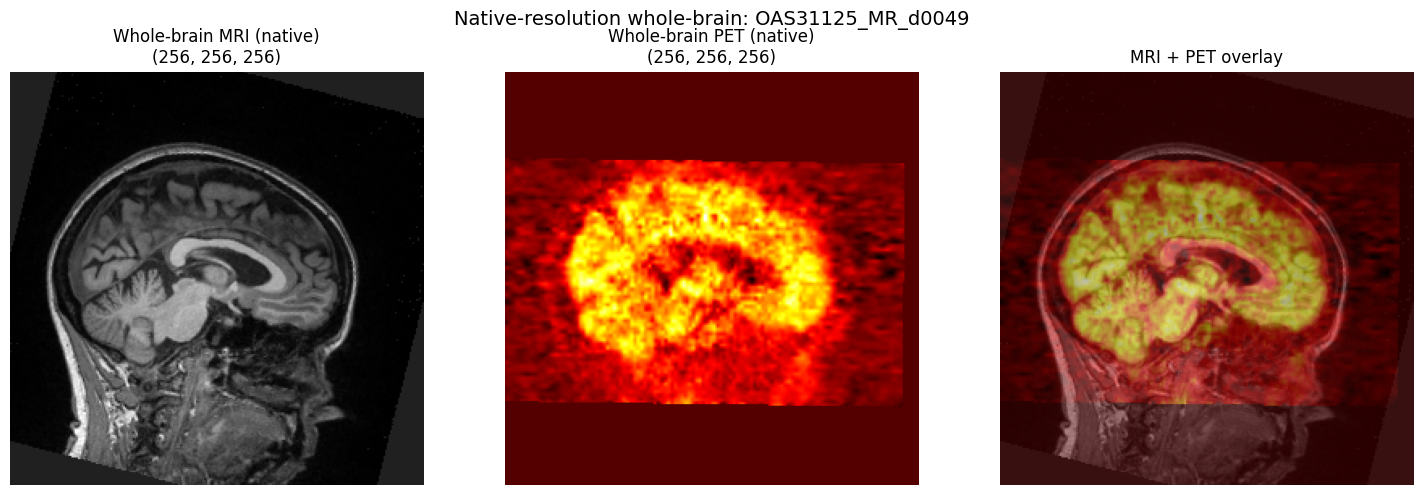

MRI shape: (256, 256, 256) -> 32768 tokens at patch_size=8
PET shape: (256, 256, 256) -> 32768 tokens at patch_size=8


In [9]:
import matplotlib.pyplot as plt

WB_MRI_CACHE_AUG = "D:/mamba_model/preprocessed_cache_wholebrain_native_mri_aug"
WB_PET_CACHE_AUG = "D:/mamba_model/preprocessed_cache_wholebrain_native_pet_aug"

session_id = X_val[0]
subject_id = session_to_subject[session_id]

mri_orig = np.load(f"{WB_MRI_CACHE_AUG}/{session_id}_orig.npy")
pet_orig = np.load(f"{WB_PET_CACHE_AUG}/{subject_id}_orig.npy")

mid = mri_orig.shape[0] // 2  # middle slice along the first axis

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mri_orig[mid, :, :], cmap='gray')
axes[0].set_title(f'Whole-brain MRI (native)\n{mri_orig.shape}')
axes[0].axis('off')

axes[1].imshow(pet_orig[mid, :, :], cmap='hot')
axes[1].set_title(f'Whole-brain PET (native)\n{pet_orig.shape}')
axes[1].axis('off')

axes[2].imshow(mri_orig[mid, :, :], cmap='gray')
axes[2].imshow(pet_orig[mid, :, :], cmap='hot', alpha=0.5)
axes[2].set_title('MRI + PET overlay')
axes[2].axis('off')

plt.suptitle(f'Native-resolution whole-brain: {session_id}', fontsize=14)
plt.tight_layout()
plt.show()

print(f"MRI shape: {mri_orig.shape} -> {(mri_orig.shape[0]//8)**3} tokens at patch_size=8")
print(f"PET shape: {pet_orig.shape} -> {(pet_orig.shape[0]//8)**3} tokens at patch_size=8")